# Homebound 프로젝트: 피처 엔지니어링

> 전처리 완료 데이터(`shelter_animals_tableau.csv`, 789,874행)에 대해 추가 피처 엔지니어링을 수행한다.
> 원본 데이터에서 `특징`(텍스트)·`발견장소` 컬럼을 보충하여 활용한다.

| Part | 작업 | 설명 |
|------|------|------|
| 1 | 보호기간일 이상치 처리 | 음수 13건, 극단값 → [0, 180] 클리핑 |
| 2 | 색상 표준화 | 82개 원본 → 12개 범주 매핑 |
| 3 | 특징 텍스트 NLP | konlpy Okt 형태소 분석, 키워드 플래그 생성 |
| 4 | 발견장소 지오코딩 | 시군구 좌표 획득, choropleth 시각화 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, os, time, re
from dotenv import load_dotenv
warnings.filterwarnings('ignore')

# .env 파일 로드
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))  # 프로젝트 루트 .env
load_dotenv()  # 현재 디렉토리 .env (있으면)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 경로 설정 ──
PROJECT = '/Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound'
RAW     = f'{PROJECT}/01_raw_data'
DATA    = f'{PROJECT}/02_outputs/data'
FIG     = f'{PROJECT}/02_outputs/figures'
os.makedirs(FIG, exist_ok=True)

print(f"프로젝트 경로: {PROJECT}")
print(f"데이터 경로 : {DATA}")
print(f"시각화 경로 : {FIG}")
print(f"KAKAO_REST_KEY: {'✅ 설정됨' if os.environ.get('KAKAO_REST_KEY') else '❌ 미설정'}")

프로젝트 경로: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
데이터 경로 : /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data
시각화 경로 : /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures
KAKAO_REST_KEY: ✅ 설정됨


---
## 데이터 로드

- **메인 데이터**: `shelter_animals_tableau.csv` (22컬럼, 전처리 완료)
- **원본 데이터**: `보호종료동물 상세 데이터.csv` (xlsx 형식, `특징`·`발견장소` 보충용)

In [2]:
# 메인 데이터 로드
df = pd.read_csv(f'{DATA}/shelter_animals_tableau.csv')
print(f"메인 데이터: {df.shape[0]:,}행 × {df.shape[1]}컬럼")

# 원본에서 특징·발견장소 컬럼 보충
raw = pd.read_excel(
    f'{RAW}/보호종료동물 상세 데이터.csv',
    engine='openpyxl',
    usecols=['특징', '발견장소']
)
print(f"원본 데이터: {raw.shape[0]:,}행 (특징·발견장소 로드)")

# 행 수 일치 확인 후 병합 (동일 순서 가정)
assert abs(len(df) - len(raw)) <= 1, f"행 수 불일치: {len(df)} vs {len(raw)}"
if len(raw) > len(df):
    raw = raw.iloc[:len(df)]
elif len(df) > len(raw):
    df = df.iloc[:len(raw)]

df['특징'] = raw['특징'].values
df['발견장소'] = raw['발견장소'].values
print(f"\n병합 후: {df.shape[0]:,}행 × {df.shape[1]}컬럼")
print(f"  특징 비결측: {df['특징'].notna().sum():,}건")
print(f"  발견장소 비결측: {df['발견장소'].notna().sum():,}건")
print(f"\n컬럼 목록: {df.columns.tolist()}")

메인 데이터: 789,874행 × 22컬럼


원본 데이터: 789,875행 (특징·발견장소 로드)

병합 후: 789,874행 × 24컬럼
  특징 비결측: 789,837건
  발견장소 비결측: 789,874건

컬럼 목록: ['접수일자', '품종', '동물종류', '품종그룹', '색상', '성별', '중성화 여부', '나이그룹', '추정나이', '60일미만', '체중_정제', '체중그룹', '종료사유_정제', '입양여부', '시도', '시군구', '보호소명', '접수년도', '접수월', '접수분기', '접수요일', '보호기간일', '특징', '발견장소']


---
## Part 1: 보호기간일 이상치 처리

**현황**
- 음수 값 13건 (데이터 오류: 최소 -3,277일)
- 극단적 최대값 72,328일 (약 198년)
- 180일 초과 27건

**처리**: `보호기간일`을 **[0, 180]** 범위로 클리핑

In [3]:
# ── 처리 전 현황 ──
col = '보호기간일'
print("=" * 60)
print("  보호기간일 이상치 현황 (처리 전)")
print("=" * 60)
print(f"  기본 통계:\n{df[col].describe()}")
print(f"\n  음수 건수      : {(df[col] < 0).sum():,}건")
print(f"  180일 초과     : {(df[col] > 180).sum():,}건")
print(f"  365일 초과     : {(df[col] > 365).sum():,}건")

# ── 처리 전 분포 저장 ──
before = df[col].copy()

# ── 클리핑 적용 ──
df[col] = df[col].clip(lower=0, upper=180)

print(f"\n  ✅ [0, 180] 클리핑 완료")
print(f"  음수 건수 (후)  : {(df[col] < 0).sum():,}건")
print(f"  180일 초과 (후) : {(df[col] > 180).sum():,}건")
print(f"  처리 후 통계:\n{df[col].describe()}")

  보호기간일 이상치 현황 (처리 전)
  기본 통계:
count    789874.000000
mean         10.599870
std          82.809647
min       -3277.000000
25%          10.000000
50%          10.000000
75%          11.000000
max       72328.000000
Name: 보호기간일, dtype: float64

  음수 건수      : 13건
  180일 초과     : 27건
  365일 초과     : 20건

  ✅ [0, 180] 클리핑 완료
  음수 건수 (후)  : 0건
  180일 초과 (후) : 0건
  처리 후 통계:
count    789874.000000
mean         10.459819
std           2.098242
min           0.000000
25%          10.000000
50%          10.000000
75%          11.000000
max         180.000000
Name: 보호기간일, dtype: float64


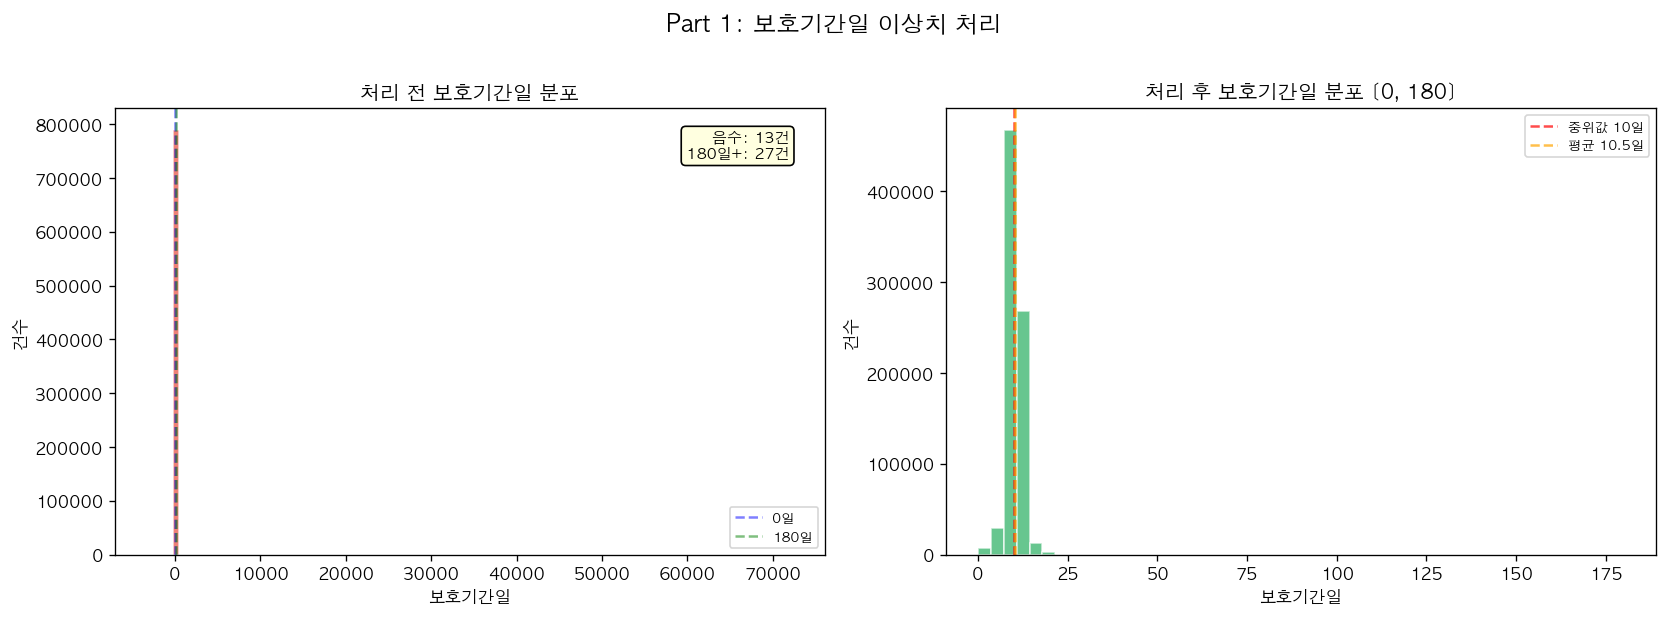

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_01_보호기간일_클리핑.png


In [4]:
# ── 시각화: 처리 전/후 히스토그램 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 처리 전
axes[0].hist(before, bins=100, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('처리 전 보호기간일 분포', fontweight='bold')
axes[0].set_xlabel('보호기간일')
axes[0].set_ylabel('건수')
axes[0].axvline(0, color='blue', ls='--', alpha=0.5, label='0일')
axes[0].axvline(180, color='green', ls='--', alpha=0.5, label='180일')
axes[0].legend(fontsize=8)
# 이상치 표시
n_neg = (before < 0).sum()
n_over = (before > 180).sum()
axes[0].text(0.95, 0.95, f'음수: {n_neg}건\n180일+: {n_over}건',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', fc='lightyellow'), fontsize=9)

# 처리 후
axes[1].hist(df['보호기간일'], bins=50, color='#27ae60', alpha=0.7, edgecolor='white')
axes[1].set_title('처리 후 보호기간일 분포 [0, 180]', fontweight='bold')
axes[1].set_xlabel('보호기간일')
axes[1].set_ylabel('건수')
axes[1].axvline(df['보호기간일'].median(), color='red', ls='--', alpha=0.7,
                label=f"중위값 {df['보호기간일'].median():.0f}일")
axes[1].axvline(df['보호기간일'].mean(), color='orange', ls='--', alpha=0.7,
                label=f"평균 {df['보호기간일'].mean():.1f}일")
axes[1].legend(fontsize=8)

fig.suptitle('Part 1: 보호기간일 이상치 처리', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_01_보호기간일_클리핑.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_01_보호기간일_클리핑.png")

---
## Part 2: 색상 표준화 (82개 → 12개 범주)

**표준 범주 체계**

| 표준 범주 | 원본 예시 |
|-----------|-----------|
| 흰색 | 흰색 |
| 검정색 | 검정색 |
| 갈색 | 갈색 |
| 황색/크림 | 황색, 노란색, 크림색 |
| 회색 | 회색 |
| 흑백 | 검정&흰색 |
| 갈백 | 갈색&흰색 |
| 갈흑 | 갈색&검정 |
| 삼색 | 갈색&흰색&검정 등 3색 조합 |
| 주황/빨강 | 주황색, 빨간색 |
| 기타축종 | 파란색, 녹색 등 (새/파충류 색상) |
| 기타 | 나머지 |

In [5]:
# ── 색상 고유값 확인 ──
print(f"색상 고유값: {df['색상'].nunique()}개\n")
vc = df['색상'].value_counts()
for v, n in vc.items():
    pct = n / len(df) * 100
    print(f"  {v:25s}: {n:>8,}건 ({pct:5.1f}%)")

색상 고유값: 82개

  기타                       :  342,199건 ( 43.3%)
  흰색                       :  174,839건 ( 22.1%)
  갈색                       :   80,998건 ( 10.3%)
  검정색                      :   42,552건 (  5.4%)
  갈색&흰색                    :   40,469건 (  5.1%)
  갈색&검정                    :   22,946건 (  2.9%)
  검정&흰색                    :   18,312건 (  2.3%)
  붉고 엷은 황갈색                :   14,156건 (  1.8%)
  크림색                      :    8,456건 (  1.1%)
  옅은 황색                    :    8,198건 (  1.0%)
  갈색&검정&흰색                 :    5,788건 (  0.7%)
  검은색흰색황토색조합               :    3,677건 (  0.5%)
  엷은 황갈색&흰색                :    3,545건 (  0.4%)
  레몬색&흰색                   :    3,452건 (  0.4%)
  흰색/검은색 얼룩무늬              :    3,313건 (  0.4%)
  황갈색                      :    3,235건 (  0.4%)
  평행·전체·부분줄무늬              :    2,052건 (  0.3%)
  회색                       :    1,816건 (  0.2%)
  노란색                      :    1,793건 (  0.2%)
  흰색&황갈색                   :    1,597건 (  0.2%)
  검정&황갈색                   

In [6]:
# ── 색상 표준화: 정확매핑 + 규칙 기반 폴백 ──

# 1단계: 정확 매핑 딕셔너리 (주요 82개 중 명확한 값)
exact_map = {
    # 단색
    '흰색': '흰색', '검정색': '검정색', '검정': '검정색',
    '갈색': '갈색', '연갈색': '갈색', '진갈색': '갈색', '초코색': '갈색', '밤색': '갈색',
    '쵸콜릿색': '갈색', '금갈색': '갈색', '흑갈색': '갈흑',
    '황색': '황색/크림', '노란색': '황색/크림', '크림색': '황색/크림', '베이지색': '황색/크림',
    '금색': '황색/크림', '아이보리': '황색/크림', '연노랑': '황색/크림', '황갈색': '황색/크림',
    '살구색': '황색/크림', '겨자색': '황색/크림',
    '회색': '회색', '은색': '회색', '은회색': '회색', '청회색': '회색',
    '진회색': '회색', '연회색': '회색', '어두운회색': '회색', '울프그레이': '회색',
    '주황색': '주황/빨강', '빨간색': '주황/빨강', '적갈색': '주황/빨강', '오렌지색': '주황/빨강',
    # 2색 - 흑백
    '검정&흰색': '흑백', '흰색&검정': '흑백', '흰색&검정색': '흑백', '검정색&흰색': '흑백',
    # 2색 - 갈백
    '갈색&흰색': '갈백', '흰색&갈색': '갈백', '연갈색&흰색': '갈백', '흰색&연갈색': '갈백',
    '흰색&진갈색': '갈백', '진갈색&흰색': '갈백', '크림색&흰색': '갈백', '흰색&크림색': '갈백',
    '베이지색&흰색': '갈백', '흰색&베이지색': '갈백', '밤색&흰색': '갈백',
    '엷은 황갈색&흰색': '갈백', '흰색&황갈색': '갈백', '금색&흰색': '황색/크림',
    # 2색 - 갈흑
    '갈색&검정': '갈흑', '갈색&검정색': '갈흑', '검정&갈색': '갈흑', '검정색&갈색': '갈흑',
    '연갈색&검정색': '갈흑', '검정색&연갈색': '갈흑', '진갈색&검정색': '갈흑', '검정색&진갈색': '갈흑',
    '검정&황갈색': '갈흑', '검정&금색': '갈흑',
    # 2색 - 기타 조합
    '갈색&황색': '갈색', '황색&갈색': '갈색', '황색&흰색': '황색/크림', '흰색&황색': '황색/크림',
    '회색&흰색': '회색', '흰색&회색': '회색', '검정색&회색': '검정색', '회색&검정색': '검정색',
    '주황색&흰색': '주황/빨강', '흰색&주황색': '주황/빨강', '주황&흰색': '주황/빨강',
    '빨간색&흰색': '주황/빨강', '레몬색&흰색': '황색/크림', '적갈&흰색': '주황/빨강',
    '검정&은색': '회색', '은색&흰색': '회색', '은색&갈색': '회색',
    '갈색&회색': '갈색', '청회색&흰색': '회색',
    # 3색 - 삼색
    '갈색&흰색&검정색': '삼색', '갈색&검정색&흰색': '삼색', '흰색&갈색&검정색': '삼색',
    '흰색&검정색&갈색': '삼색', '검정색&갈색&흰색': '삼색', '검정색&흰색&갈색': '삼색',
    '흰색&갈색&검정': '삼색', '검정&흰색&갈색': '삼색', '갈색&흰색&검정': '삼색',
    '갈색&검정&흰색': '삼색', '검은색흰색황토색조합': '삼색', '검정 황갈색&흰색': '삼색',
    '흰색&갈색&탄': '삼색', '적갈&검정&흰색': '삼색', '검정&황갈색&흰색': '삼색',
    '갈색&회색&흰색': '삼색',
    # 기타축종 (새·파충류)
    '파란색': '기타축종', '녹색': '기타축종', '보라색': '기타축종', '분홍색': '기타축종',
    '청색': '기타축종', '금청색(금빛을 띤 청색)': '기타축종', 'BLUE&GOLD': '기타축종',
}

# 2단계: 규칙 기반 폴백 (딕셔너리에 없는 경우)
def classify_color(raw):
    """정확매핑 → 규칙 기반 폴백으로 색상 표준화"""
    if pd.isna(raw):
        return '기타'
    # 정확 매핑
    if raw in exact_map:
        return exact_map[raw]
    # 원본 '기타'는 그대로
    if raw == '기타':
        return '기타'
    
    s = str(raw)
    # 3색 이상 조합 감지 (&가 2개 이상 또는 색상 키워드 3개+)
    color_kws = ['흰', '검', '갈', '황', '회', '주황', '빨', '금', '은', '적갈']
    matched = sum(1 for kw in color_kws if kw in s)
    if matched >= 3 or s.count('&') >= 2:
        return '삼색'
    # 얼룩/줄무늬 + 특정 색
    if '얼룩' in s or '줄무늬' in s or '반점' in s:
        if '흰' in s and ('검' in s or '흑' in s):
            return '흑백'
        if '회' in s or '은' in s:
            return '회색'
        if '갈' in s:
            return '갈색'
        return '기타'
    # 2색 조합 (& 포함)
    if '&' in s or '/' in s:
        has_white = '흰' in s or '백' in s
        has_black = '검' in s or '흑' in s
        has_brown = '갈' in s or '밤' in s or '초코' in s
        if has_white and has_black:
            return '흑백'
        if has_white and has_brown:
            return '갈백'
        if has_black and has_brown:
            return '갈흑'
    # 단색 규칙
    if '황갈' in s or '옅은 황' in s or '엷은 황' in s or '레몬' in s or '밝은 금' in s:
        return '황색/크림'
    if '호반' in s:
        return '갈색'
    if '크림' in s or '베이지' in s or '노란' in s or '금' in s:
        return '황색/크림'
    if '회' in s or '은색' in s or '그레이' in s:
        return '회색'
    if '갈' in s or '밤' in s or '초코' in s or '고동' in s or '브라운' in s:
        return '갈색'
    if '검' in s or '흑' in s:
        return '검정색'
    if '흰' in s or '하얀' in s or '백' in s:
        return '흰색'
    if '주황' in s or '빨' in s or '적갈' in s or '오렌지' in s:
        return '주황/빨강'
    if '파란' in s or '녹' in s or '보라' in s or '청' in s:
        return '기타축종'
    return '기타'

df['색상_표준'] = df['색상'].apply(classify_color)

# 매핑 결과 확인
print("=" * 60)
print("  색상 표준화 결과 (정확매핑 + 규칙 기반)")
print("=" * 60)
print(f"  원본: {df['색상'].nunique()}개 → 표준: {df['색상_표준'].nunique()}개\n")

std_vc = df['색상_표준'].value_counts()
for v, n in std_vc.items():
    pct = n / len(df) * 100
    print(f"  {v:10s}: {n:>8,}건 ({pct:5.1f}%)")

# 매핑 누락 확인
unmapped = df[df['색상_표준'] == '기타']['색상'].value_counts()
print(f"\n  '기타'로 분류된 원본 색상 ({len(unmapped)}종, {unmapped.sum():,}건):")
for v, n in unmapped.head(10).items():
    print(f"    {v}: {n:,}건")

  색상 표준화 결과 (정확매핑 + 규칙 기반)


  원본: 82개 → 표준: 12개

  기타        :  344,420건 ( 43.6%)
  흰색        :  174,839건 ( 22.1%)
  갈색        :   82,482건 ( 10.4%)
  갈백        :   45,653건 (  5.8%)
  검정색       :   42,560건 (  5.4%)
  삼색        :   28,262건 (  3.6%)
  황색/크림     :   26,221건 (  3.3%)
  갈흑        :   24,625건 (  3.1%)
  흑백        :   18,312건 (  2.3%)
  회색        :    2,298건 (  0.3%)
  주황/빨강     :      195건 (  0.0%)
  기타축종      :        7건 (  0.0%)



  '기타'로 분류된 원본 색상 (5종, 344,420건):
    기타: 342,199건
    평행·전체·부분줄무늬: 2,052건
    하얀바탕에 한가지색 또는 두가지색의 명확한 반점: 96건
    얼룩무늬: 62건
    흰색/줄무늬: 11건


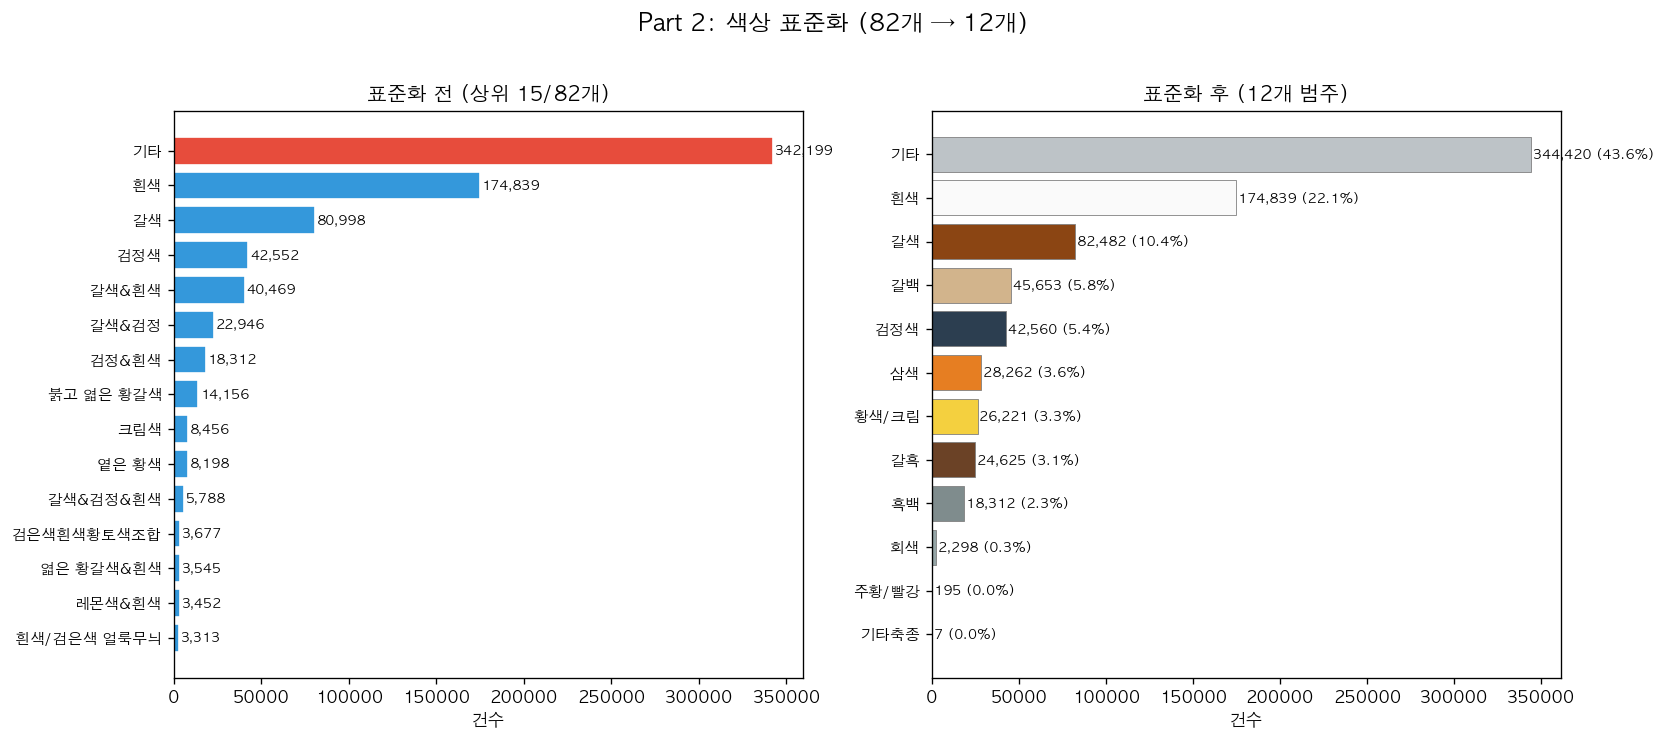

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_02_색상_표준화.png


In [7]:
# ── 시각화: 색상 표준화 전/후 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 처리 전 (상위 15개)
top15 = df['색상'].value_counts().head(15)
colors_before = ['#e74c3c' if v == '기타' else '#3498db' for v in top15.index]
axes[0].barh(range(len(top15)), top15.values, color=colors_before, edgecolor='white')
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(top15.index, fontsize=9)
axes[0].set_xlabel('건수')
axes[0].set_title(f'표준화 전 (상위 15/{df["색상"].nunique()}개)', fontweight='bold')
axes[0].invert_yaxis()
for i, (v, n) in enumerate(zip(top15.values, top15.values)):
    axes[0].text(v + 1000, i, f'{n:,}', va='center', fontsize=8)

# 처리 후
std_vc = df['색상_표준'].value_counts()
palette = {
    '흰색': '#FAFAFA', '검정색': '#2C3E50', '갈색': '#8B4513',
    '황색/크림': '#F4D03F', '회색': '#95A5A6', '주황/빨강': '#E74C3C',
    '흑백': '#7F8C8D', '갈백': '#D2B48C', '갈흑': '#6B4226',
    '삼색': '#E67E22', '기타축종': '#9B59B6', '기타': '#BDC3C7'
}
bar_colors = [palette.get(v, '#BDC3C7') for v in std_vc.index]
bars = axes[1].barh(range(len(std_vc)), std_vc.values, color=bar_colors,
                    edgecolor='gray', linewidth=0.5)
axes[1].set_yticks(range(len(std_vc)))
axes[1].set_yticklabels(std_vc.index, fontsize=9)
axes[1].set_xlabel('건수')
axes[1].set_title(f'표준화 후 ({len(std_vc)}개 범주)', fontweight='bold')
axes[1].invert_yaxis()
for i, n in enumerate(std_vc.values):
    pct = n / len(df) * 100
    axes[1].text(n + 1000, i, f'{n:,} ({pct:.1f}%)', va='center', fontsize=8)

fig.suptitle('Part 2: 색상 표준화 (82개 → 12개)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_02_색상_표준화.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_02_색상_표준화.png")

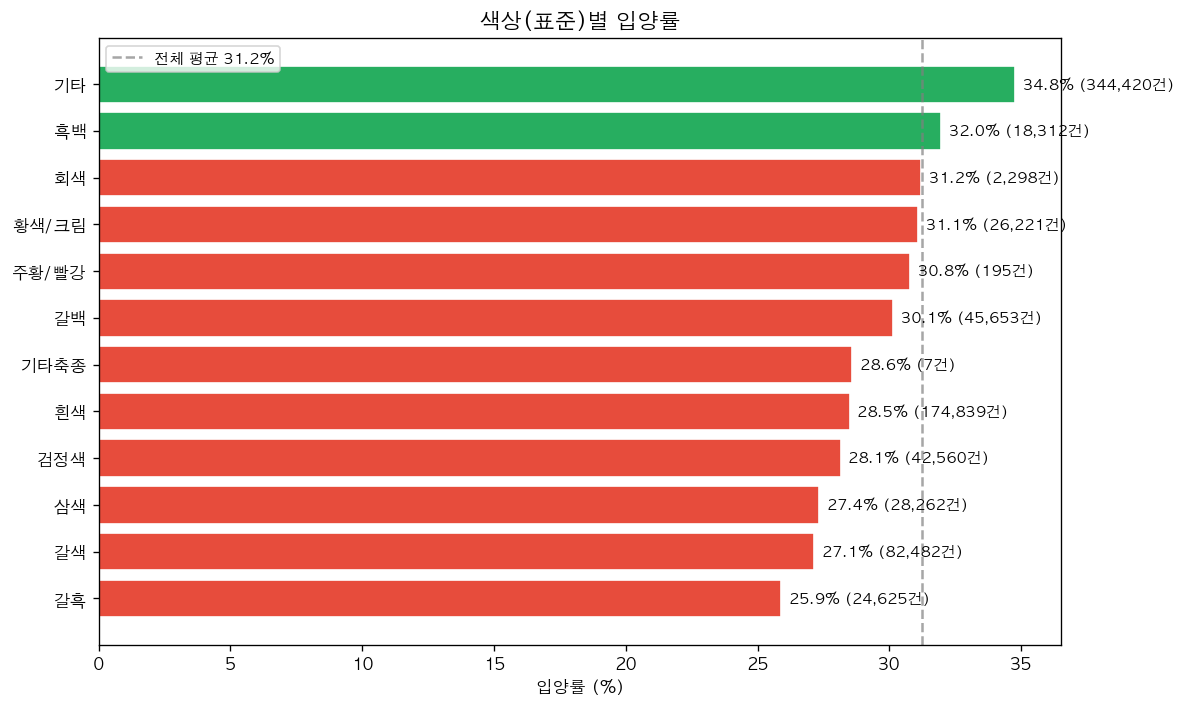

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_03_색상별_입양률.png


In [8]:
# ── 색상별 입양률 분석 ──
color_adopt = df.groupby('색상_표준').agg(
    총건수=('입양여부', 'count'),
    입양건수=('입양여부', 'sum')
).reset_index()
color_adopt['입양률'] = (color_adopt['입양건수'] / color_adopt['총건수'] * 100).round(2)
color_adopt = color_adopt.sort_values('입양률', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
avg_rate = df['입양여부'].mean() * 100
colors = ['#27ae60' if r > avg_rate else '#e74c3c' for r in color_adopt['입양률']]
bars = ax.barh(range(len(color_adopt)), color_adopt['입양률'], color=colors, edgecolor='white')
ax.set_yticks(range(len(color_adopt)))
ax.set_yticklabels(color_adopt['색상_표준'], fontsize=10)
ax.axvline(avg_rate, color='gray', ls='--', alpha=0.7, label=f'전체 평균 {avg_rate:.1f}%')
for i, (r, n) in enumerate(zip(color_adopt['입양률'], color_adopt['총건수'])):
    ax.text(r + 0.3, i, f'{r:.1f}% ({n:,}건)', va='center', fontsize=9)
ax.set_xlabel('입양률 (%)')
ax.set_title('색상(표준)별 입양률', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_03_색상별_입양률.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_03_색상별_입양률.png")

---
## Part 3: 특징 텍스트 NLP (konlpy Okt)

- konlpy의 Okt 형태소 분석기를 사용하여 `특징` 텍스트 분석
- 명사·형용사 추출 → 키워드 빈도 분석 → WordCloud
- 입양/비입양 그룹별 키워드 차이 분석
- 핵심 키워드 플래그 변수 생성

In [9]:
from konlpy.tag import Okt
from collections import Counter
from wordcloud import WordCloud

okt = Okt()

# ── 텍스트 전처리 ──
texts = df['특징'].dropna().astype(str)
print(f"분석 대상 텍스트: {len(texts):,}건")
print(f"샘플:")
for t in texts.sample(5, random_state=42):
    print(f"  → {t[:80]}")

분석 대상 텍스트: 789,837건
샘플:
  → 핑크색코, 털이많이 뭉쳐있음, 눈에 고름이 보임, 순하고 사람잘따른다
  → 소심하지만 작고 튼튼한 몸을 가진 개
  → 3개월 추정, 겁이 많음
  → 유순하고 사람을 잘 따름
  → 생후 80일령 추정, 인근 농가에 들어와서 구조


In [10]:
# ── 형태소 분석: 명사·형용사 추출 ──
# (전체 79만건은 시간이 걸리므로 3만건 샘플링 후 전체 추정)
sample_size = 30_000
np.random.seed(42)
sample_idx = np.random.choice(texts.index, size=min(sample_size, len(texts)), replace=False)
sample_texts = texts.loc[sample_idx]

print(f"형태소 분석 중... (샘플 {len(sample_texts):,}건)")

# 입양/비입양 인덱스를 set으로 변환 (O(1) 탐색)
adopted_set = set(sample_idx[df.loc[sample_idx, '입양여부'] == 1])

all_words = Counter()
adopted_words = Counter()
not_adopted_words = Counter()

for i, (idx, text) in enumerate(sample_texts.items()):
    if i % 5000 == 0:
        print(f"  진행: {i:,}/{len(sample_texts):,} ({i/len(sample_texts)*100:.0f}%)")
    try:
        pos = okt.pos(str(text), stem=True)
        words = [w for w, p in pos if p in ('Noun', 'Adjective') and len(w) > 1]
        all_words.update(words)
        if idx in adopted_set:
            adopted_words.update(words)
        else:
            not_adopted_words.update(words)
    except:
        continue

print(f"\n추출된 고유 단어: {len(all_words):,}개")
print(f"\n전체 키워드 Top 30:")
for word, cnt in all_words.most_common(30):
    print(f"  {word:10s}: {cnt:>6,}회")

형태소 분석 중... (샘플 30,000건)
  진행: 0/30,000 (0%)


  진행: 5,000/30,000 (17%)


  진행: 10,000/30,000 (33%)


  진행: 15,000/30,000 (50%)


  진행: 20,000/30,000 (67%)


  진행: 25,000/30,000 (83%)



추출된 고유 단어: 5,169개

전체 키워드 Top 30:
  순하다       :  3,048회
  추정        :  2,992회
  개월        :  2,592회
  사람        :  2,439회
  있다        :  2,296회
  상태        :  2,130회
  온순하다      :  2,087회
  관리        :  1,930회
  없다        :  1,908회
  생후        :  1,720회
  목줄        :  1,701회
  착용        :  1,586회
  번호        :  1,571회
  꼬리        :  1,467회
  많다        :  1,434회
  구조        :  1,417회
  개체        :  1,411회
  마리        :  1,318회
  양호        :  1,249회
  검정        :  1,210회
  심하다       :  1,063회
  갈색        :    928회
  어미        :    921회
  기력        :    898회
  매우        :    876회
  경계        :    876회
  좋아하다      :    860회
  흰색        :    841회
  온순        :    838회
  미안        :    801회


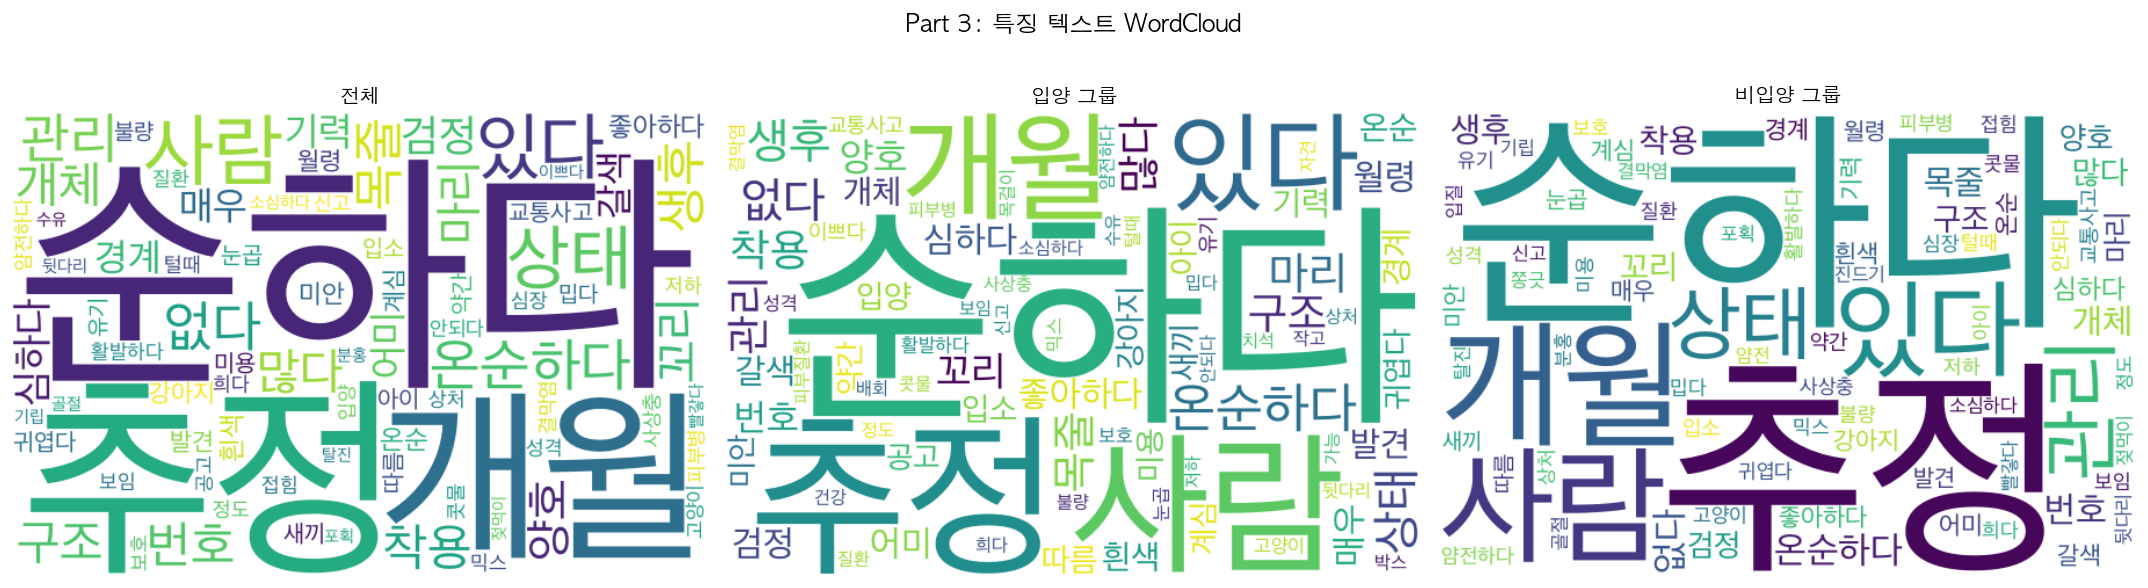

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_04_특징_워드클라우드.png


In [11]:
# ── WordCloud 시각화 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'

for ax, words, title in [
    (axes[0], all_words, '전체'),
    (axes[1], adopted_words, '입양 그룹'),
    (axes[2], not_adopted_words, '비입양 그룹'),
]:
    wc = WordCloud(
        font_path=font_path, width=600, height=400,
        background_color='white', max_words=80,
        colormap='viridis', prefer_horizontal=0.7
    ).generate_from_frequencies(dict(words.most_common(200)))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

fig.suptitle('Part 3: 특징 텍스트 WordCloud', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_04_특징_워드클라우드.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_04_특징_워드클라우드.png")

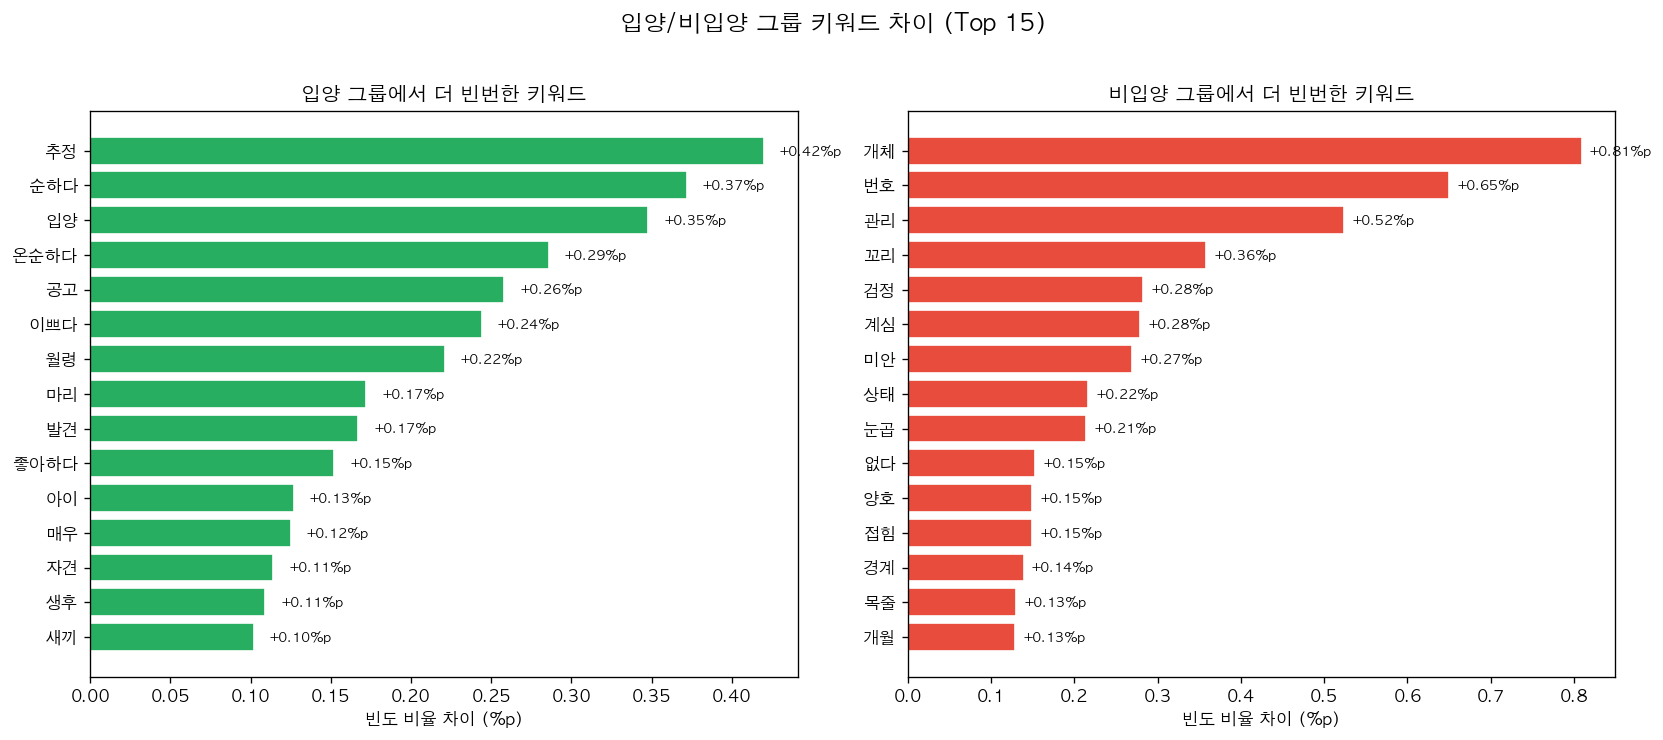

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_05_키워드_입양차이.png


In [12]:
# ── 입양/비입양 키워드 차이 분석 ──
# 각 그룹에서 빈도 비율 계산 후 차이가 큰 키워드 추출
top_words = [w for w, _ in all_words.most_common(100)]

adopt_total = sum(adopted_words.values())
not_total = sum(not_adopted_words.values())

keyword_diff = []
for w in top_words:
    a_rate = adopted_words[w] / adopt_total * 100 if adopt_total > 0 else 0
    n_rate = not_adopted_words[w] / not_total * 100 if not_total > 0 else 0
    diff = a_rate - n_rate
    keyword_diff.append({
        '키워드': w,
        '입양빈도': adopted_words[w],
        '비입양빈도': not_adopted_words[w],
        '입양비율': round(a_rate, 3),
        '비입양비율': round(n_rate, 3),
        '차이': round(diff, 3)
    })

kdf = pd.DataFrame(keyword_diff).sort_values('차이', ascending=False)

# 입양과 관련 높은 키워드 / 비입양과 관련 높은 키워드
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 입양과 관련 높은 키워드 (Top 15)
top_adopt = kdf.head(15).sort_values('차이')
axes[0].barh(range(len(top_adopt)), top_adopt['차이'], color='#27ae60', edgecolor='white')
axes[0].set_yticks(range(len(top_adopt)))
axes[0].set_yticklabels(top_adopt['키워드'], fontsize=10)
axes[0].set_xlabel('빈도 비율 차이 (%p)')
axes[0].set_title('입양 그룹에서 더 빈번한 키워드', fontweight='bold')
for i, v in enumerate(top_adopt['차이']):
    axes[0].text(v + 0.01, i, f'+{v:.2f}%p', va='center', fontsize=8)

# 비입양과 관련 높은 키워드 (Bottom 15)
top_not = kdf.tail(15).sort_values('차이', ascending=False)
axes[1].barh(range(len(top_not)), top_not['차이'].abs(), color='#e74c3c', edgecolor='white')
axes[1].set_yticks(range(len(top_not)))
axes[1].set_yticklabels(top_not['키워드'], fontsize=10)
axes[1].set_xlabel('빈도 비율 차이 (%p)')
axes[1].set_title('비입양 그룹에서 더 빈번한 키워드', fontweight='bold')
for i, v in enumerate(top_not['차이'].abs()):
    axes[1].text(v + 0.01, i, f'+{v:.2f}%p', va='center', fontsize=8)

fig.suptitle('입양/비입양 그룹 키워드 차이 (Top 15)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_05_키워드_입양차이.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_05_키워드_입양차이.png")

In [13]:
# ── 핵심 키워드 플래그 변수 생성 ──
# 입양 관련 긍정 키워드 (위 분석 + 도메인 지식 기반)
positive_keywords = ['온순', '순하다', '활발', '건강', '사람', '친화', '좋다', '예쁘다',
                     '착하다', '귀엽다', '사교', '밝다', '애교', '순한']
negative_keywords = ['겁', '공격', '경계', '짖다', '물다', '질병', '골절', '피부',
                     '눈병', '구내염', '마비', '사망', '위험', '흉포']

def check_keywords(text, keywords):
    """텍스트에 키워드가 포함되어 있는지 확인"""
    if pd.isna(text):
        return 0
    text = str(text)
    return int(any(kw in text for kw in keywords))

# 플래그 컬럼 생성
df['is_온순'] = df['특징'].apply(lambda x: check_keywords(x, ['온순', '순하다', '순한', '순함']))
df['is_활발'] = df['특징'].apply(lambda x: check_keywords(x, ['활발', '활동', '명랑', '밝다']))
df['is_건강'] = df['특징'].apply(lambda x: check_keywords(x, ['건강', '양호', '이상없']))
df['is_친화'] = df['특징'].apply(lambda x: check_keywords(x, ['사람', '친화', '사교', '좋아']))
df['is_겁많음'] = df['특징'].apply(lambda x: check_keywords(x, ['겁', '경계', '불안', '예민']))
df['is_공격성'] = df['특징'].apply(lambda x: check_keywords(x, ['공격', '물다', '흉포', '위험']))
df['is_질병'] = df['특징'].apply(lambda x: check_keywords(x, ['질병', '골절', '피부', '눈병', '구내염', '마비']))

flag_cols = ['is_온순', 'is_활발', 'is_건강', 'is_친화', 'is_겁많음', 'is_공격성', 'is_질병']
print("키워드 플래그 변수 생성 완료:\n")
for col in flag_cols:
    n = df[col].sum()
    rate = df[df[col] == 1]['입양여부'].mean() * 100
    avg = df['입양여부'].mean() * 100
    diff = rate - avg
    print(f"  {col:12s}: {n:>7,}건 | 입양률 {rate:.1f}% (전체 대비 {diff:+.1f}%p)")

키워드 플래그 변수 생성 완료:

  is_온순       : 136,464건 | 입양률 33.0% (전체 대비 +1.8%p)
  is_활발       :  15,216건 | 입양률 31.7% (전체 대비 +0.5%p)
  is_건강       :  41,660건 | 입양률 28.7% (전체 대비 -2.5%p)
  is_친화       :  73,147건 | 입양률 30.6% (전체 대비 -0.6%p)
  is_겁많음      :  87,131건 | 입양률 26.6% (전체 대비 -4.6%p)
  is_공격성      :   4,763건 | 입양률 23.1% (전체 대비 -8.1%p)
  is_질병       :  37,308건 | 입양률 31.3% (전체 대비 +0.1%p)


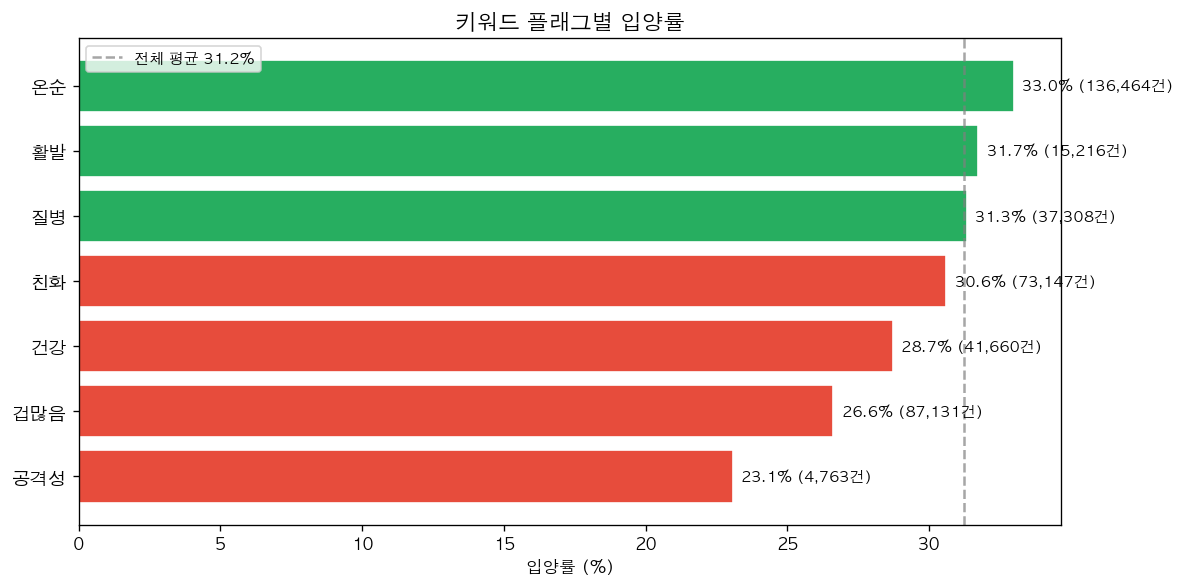

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_06_키워드_입양률.png


In [14]:
# ── 키워드 플래그별 입양률 시각화 ──
flag_rates = []
avg_rate = df['입양여부'].mean() * 100
for col in flag_cols:
    n = df[col].sum()
    if n > 0:
        rate = df[df[col] == 1]['입양여부'].mean() * 100
    else:
        rate = 0
    flag_rates.append({'키워드': col.replace('is_', ''), '건수': n, '입양률': rate})

fdf = pd.DataFrame(flag_rates).sort_values('입양률', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if r > avg_rate else '#e74c3c' for r in fdf['입양률']]
bars = ax.barh(range(len(fdf)), fdf['입양률'], color=colors, edgecolor='white')
ax.set_yticks(range(len(fdf)))
ax.set_yticklabels(fdf['키워드'], fontsize=11)
ax.axvline(avg_rate, color='gray', ls='--', alpha=0.7, label=f'전체 평균 {avg_rate:.1f}%')

for i, (r, n) in enumerate(zip(fdf['입양률'], fdf['건수'])):
    ax.text(r + 0.3, i, f'{r:.1f}% ({n:,}건)', va='center', fontsize=9)

ax.set_xlabel('입양률 (%)')
ax.set_title('키워드 플래그별 입양률', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_06_키워드_입양률.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_06_키워드_입양률.png")

---
## Part 4: 발견장소 지오코딩 (카카오 API)

### Phase A: 시군구 단위 좌표 획득
- `시도` + `시군구` 조합으로 210개 주소 → 카카오 API로 좌표 획득
- choropleth 지도 시각화

### Phase B: 발견장소 개별 지오코딩
- 상위 빈도 주소 10,000개 처리
- 일 30,000건 제한 고려 → 배치 처리 + 중간 저장

> **카카오 REST API 키가 필요합니다.** 아래 셀에서 API 키를 설정해주세요.

In [15]:
import requests
import folium

# ── 카카오 API 키 설정 (환경변수에서 로드) ──
# 터미널에서 설정: export KAKAO_REST_KEY='your_api_key'
# 또는 .env 파일에 KAKAO_REST_KEY=your_api_key 작성
KAKAO_REST_KEY = os.environ.get('KAKAO_REST_KEY', '')

if not KAKAO_REST_KEY:
    print("⚠️  환경변수 KAKAO_REST_KEY가 설정되지 않았습니다.")
    print("   터미널: export KAKAO_REST_KEY='your_api_key'")
    print("   또는 .env 파일 생성 후 노트북 재시작")
    print("   https://developers.kakao.com → 앱 설정 → 카카오맵 활성화 필요")
else:
    test_resp = requests.get(
        'https://dapi.kakao.com/v2/local/search/address.json',
        headers={'Authorization': f'KakaoAK {KAKAO_REST_KEY}'},
        params={'query': '서울특별시 강남구'}, timeout=5
    )
    if test_resp.status_code == 200:
        print(f"✅ 카카오 API 연결 성공")
    else:
        print(f"❌ API 오류: {test_resp.json().get('message', test_resp.status_code)}")
        print("   앱 설정 → 제품 설정 → '카카오맵' 서비스 활성화를 확인하세요.")
        KAKAO_REST_KEY = ''

✅ 카카오 API 연결 성공


In [16]:
# ── Phase A: 시군구 단위 좌표 획득 ──
def geocode_kakao(address, api_key):
    """카카오 API로 주소 → 좌표 변환"""
    url = 'https://dapi.kakao.com/v2/local/search/address.json'
    headers = {'Authorization': f'KakaoAK {api_key}'}
    params = {'query': address}
    try:
        resp = requests.get(url, headers=headers, params=params, timeout=5)
        if resp.status_code == 200:
            data = resp.json()
            if data['documents']:
                doc = data['documents'][0]
                return float(doc['y']), float(doc['x'])  # lat, lng
    except:
        pass
    return None, None

# 시군구 목록 생성
sigungu = df.groupby(['시도', '시군구']).agg(
    총건수=('입양여부', 'count'),
    입양건수=('입양여부', 'sum')
).reset_index()
sigungu['입양률'] = (sigungu['입양건수'] / sigungu['총건수'] * 100).round(2)
sigungu['주소'] = sigungu['시도'] + ' ' + sigungu['시군구']

print(f"시군구 수: {len(sigungu)}개")

if not KAKAO_REST_KEY:
    print("\n⚠️  API 키 미설정 → 지오코딩 건너뜀")
    sigungu['lat'] = None
    sigungu['lng'] = None
else:
    print("시군구 지오코딩 중...")
    lats, lngs = [], []
    for i, addr in enumerate(sigungu['주소']):
        if i % 50 == 0:
            print(f"  진행: {i}/{len(sigungu)}")
        lat, lng = geocode_kakao(addr, KAKAO_REST_KEY)
        lats.append(lat)
        lngs.append(lng)
        time.sleep(0.05)  # API 부하 방지
    sigungu['lat'] = lats
    sigungu['lng'] = lngs
    success = sigungu['lat'].notna().sum()
    print(f"\n✅ 지오코딩 완료: {success}/{len(sigungu)}개 성공")

# 저장
sigungu.to_csv(f'{DATA}/geocoded_sigungu.csv', index=False)
print(f"💾 저장: {DATA}/geocoded_sigungu.csv")
sigungu.head()

시군구 수: 232개
시군구 지오코딩 중...
  진행: 0/232


  진행: 50/232


  진행: 100/232


  진행: 150/232


  진행: 200/232



✅ 지오코딩 완료: 232/232개 성공
💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/geocoded_sigungu.csv


,시도,시군구,총건수,입양건수,입양률,주소,lat,lng
0,강원특별자치도,강릉시,4355,2288,52.54,강원특별자치도 강릉시,37.752112,128.875906
1,강원특별자치도,고성군,1464,272,18.58,강원특별자치도 고성군,38.380592,128.467866
2,강원특별자치도,동해시,1628,421,25.86,강원특별자치도 동해시,37.524742,129.114299
3,강원특별자치도,삼척시,1299,391,30.10,강원특별자치도 삼척시,37.449898,129.165112
4,강원특별자치도,속초시,2469,804,32.56,강원특별자치도 속초시,38.206894,128.591939


In [17]:
# ── Phase A 시각화: 시군구 버블맵 ──
geo_ok = sigungu[sigungu['lat'].notna()].copy()

if len(geo_ok) > 0:
    # folium 지도
    center_lat = geo_ok['lat'].mean()
    center_lng = geo_ok['lng'].mean()
    m = folium.Map(location=[center_lat, center_lng], zoom_start=7,
                   tiles='CartoDB positron')

    # 건수 기반 버블 크기, 입양률 기반 색상
    max_cnt = geo_ok['총건수'].max()
    for _, row in geo_ok.iterrows():
        radius = max(3, (row['총건수'] / max_cnt) * 30)
        color = '#27ae60' if row['입양률'] > sigungu['입양률'].median() else '#e74c3c'
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=radius,
            color=color, fill=True, fill_color=color, fill_opacity=0.6,
            popup=f"{row['시도']} {row['시군구']}<br>건수: {row['총건수']:,}<br>입양률: {row['입양률']:.1f}%",
            tooltip=f"{row['시군구']} ({row['입양률']:.1f}%)"
        ).add_to(m)

    m.save(f'{FIG}/FE_07_시군구_지도.html')
    print(f"💾 저장: {FIG}/FE_07_시군구_지도.html")
    display(m)
else:
    print("⚠️  좌표 데이터 없음 → 지도 생성 건너뜀")

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_07_시군구_지도.html


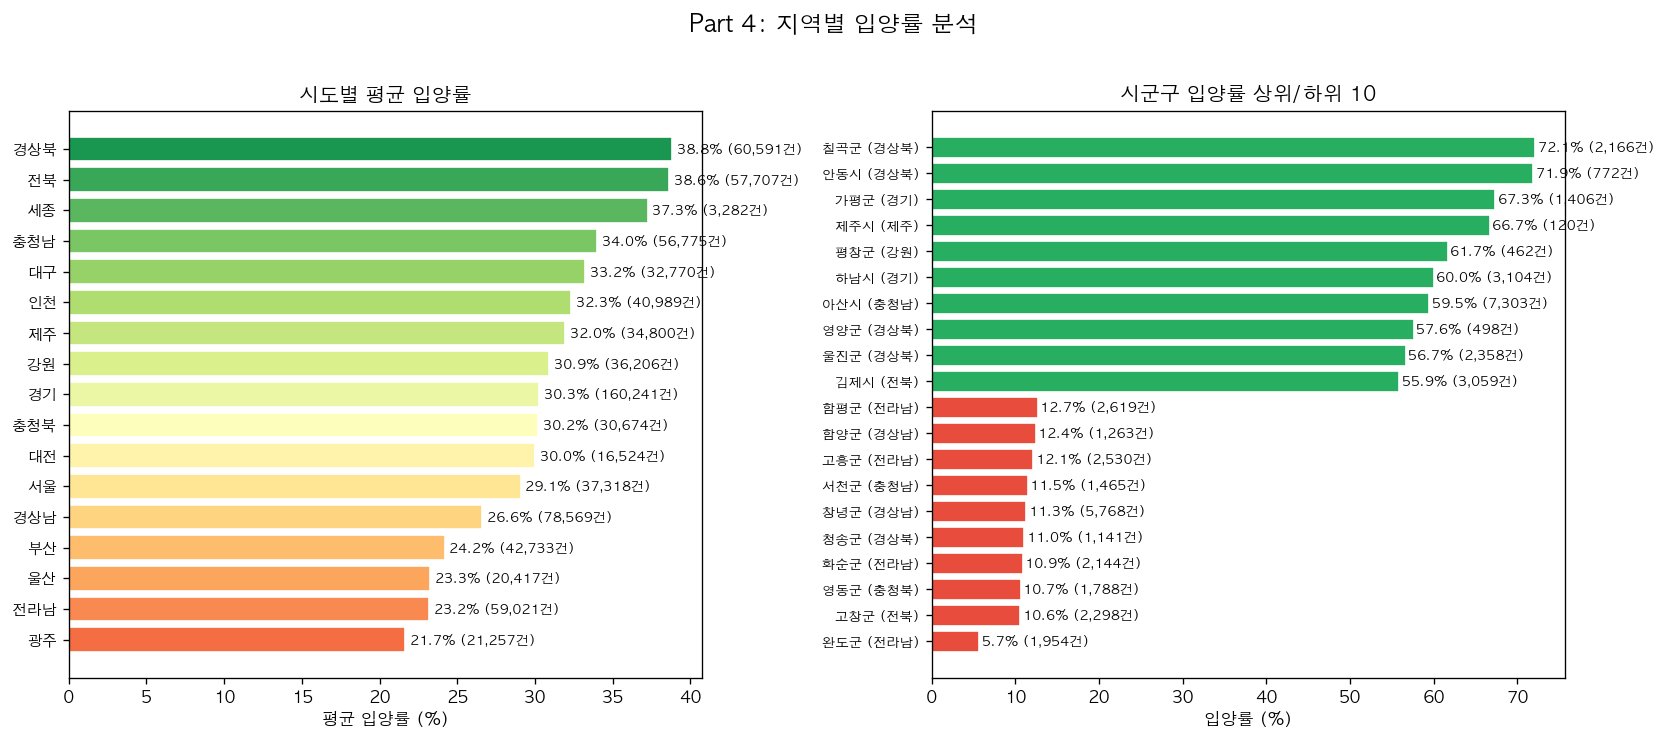

💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_08_지역별_입양률.png


In [18]:
# ── 시군구별 입양률 matplotlib 시각화 (API 키 없어도 동작) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 시도별 입양률 + 시군구 분포
sido_stats = sigungu.groupby('시도').agg(
    시군구수=('시군구', 'count'),
    평균입양률=('입양률', 'mean'),
    총건수=('총건수', 'sum')
).reset_index().sort_values('평균입양률', ascending=True)

short = lambda s: s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','').replace('도','')
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sido_stats)))
bars = axes[0].barh(range(len(sido_stats)), sido_stats['평균입양률'], color=colors, edgecolor='white')
axes[0].set_yticks(range(len(sido_stats)))
axes[0].set_yticklabels([short(s) for s in sido_stats['시도']], fontsize=9)
axes[0].set_xlabel('평균 입양률 (%)')
axes[0].set_title('시도별 평균 입양률', fontweight='bold')
for i, (r, n) in enumerate(zip(sido_stats['평균입양률'], sido_stats['총건수'])):
    axes[0].text(r + 0.3, i, f'{r:.1f}% ({n:,}건)', va='center', fontsize=8)

# 입양률 상위/하위 시군구
top10 = sigungu.nlargest(10, '입양률')
bot10 = sigungu[sigungu['총건수'] >= 100].nsmallest(10, '입양률')  # 최소 100건
combined = pd.concat([top10, bot10]).drop_duplicates()
combined = combined.sort_values('입양률', ascending=True)
labels = [f"{row['시군구']} ({short(row['시도'])})" for _, row in combined.iterrows()]
cols = ['#27ae60' if r > 40 else '#e74c3c' if r < 20 else '#3498db' for r in combined['입양률']]
bars = axes[1].barh(range(len(combined)), combined['입양률'], color=cols, edgecolor='white')
axes[1].set_yticks(range(len(combined)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel('입양률 (%)')
axes[1].set_title('시군구 입양률 상위/하위 10', fontweight='bold')
for i, (r, n) in enumerate(zip(combined['입양률'], combined['총건수'])):
    axes[1].text(r + 0.3, i, f'{r:.1f}% ({n:,}건)', va='center', fontsize=8)

fig.suptitle('Part 4: 지역별 입양률 분석', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}/FE_08_지역별_입양률.png', bbox_inches='tight')
plt.show()
print(f"💾 저장: {FIG}/FE_08_지역별_입양률.png")

In [19]:
# ── Phase B: 발견장소 개별 지오코딩 (상위 빈도순) ──
location_freq = df['발견장소'].value_counts()
print(f"발견장소 고유값: {len(location_freq):,}개")
print(f"\n상위 20개:")
for loc, cnt in location_freq.head(20).items():
    print(f"  {loc[:40]:40s}: {cnt:>5,}건")

top_locations = location_freq.head(10_000)

if not KAKAO_REST_KEY:
    print("\n⚠️  API 키 미설정 → 개별 지오코딩 건너뜀")
    print("   API 키 설정 후 이 셀을 다시 실행해주세요.")
else:
    geocoded_path = f'{DATA}/geocoded_addresses.csv'
    if os.path.exists(geocoded_path):
        existing = pd.read_csv(geocoded_path)
        # 좌표 획득 성공한 것만 기존 결과로 인정
        existing_ok = existing[existing['lat'].notna()]
        existing_set = set(existing_ok['발견장소'].values)
        print(f"\n기존 지오코딩 결과: {len(existing_ok):,}건 (좌표 있는 것만)")
    else:
        existing_ok = pd.DataFrame(columns=['발견장소', '빈도', 'lat', 'lng'])
        existing_set = set()

    to_geocode = [(loc, cnt) for loc, cnt in top_locations.items()
                  if loc not in existing_set]
    print(f"처리 대상: {len(to_geocode):,}건 (기존 제외)")

    if len(to_geocode) > 0:
        results = []
        for i, (loc, cnt) in enumerate(to_geocode[:10_000]):
            if i % 1000 == 0 and i > 0:
                print(f"  진행: {i:,}/{min(len(to_geocode), 10_000):,}")
                if results:
                    new_df = pd.DataFrame(results)
                    combined = pd.concat([existing_ok, new_df], ignore_index=True)
                    combined.to_csv(geocoded_path, index=False)
                    results = []

            lat, lng = geocode_kakao(str(loc), KAKAO_REST_KEY)
            results.append({'발견장소': loc, '빈도': cnt, 'lat': lat, 'lng': lng})
            time.sleep(0.03)

        if results:
            new_df = pd.DataFrame(results)
            combined = pd.concat([existing_ok, new_df], ignore_index=True)
        else:
            combined = existing_ok
        combined.to_csv(geocoded_path, index=False)
        success = combined['lat'].notna().sum()
        print(f"\n✅ 지오코딩 완료: {success}/{len(combined)}건 성공")
        print(f"💾 저장: {geocoded_path}")
    else:
        print("모든 주소가 이미 처리됨")

발견장소 고유값: 431,690개

상위 20개:
  삼랑진                                     : 2,214건
  상남                                      : 1,200건
  성호대로141                                 :   838건
  하남                                      :   710건
  시흥시농업기술센터에서 인수                          :   650건
  부북                                      :   633건
  옥천읍                                     :   569건
  구청당직실                                   :   564건
  구청 당직실                                  :   563건
  산내                                      :   552건
  북구 용봉동                                  :   548건
  합천읍                                     :   532건
  서구 화정동                                  :   506건
  중리동 부악로                                 :   502건
  서구 쌍촌동                                  :   494건
  북구 두암동                                  :   492건
  무안                                      :   476건
  부평구청 당직실                                :   448건
  압해읍                                     :   438건
  김

  진행: 1,000/10,000


  진행: 2,000/10,000


  진행: 3,000/10,000


  진행: 4,000/10,000


...

  진행: 6,000/10,000


  진행: 7,000/10,000


  진행: 8,000/10,000


  진행: 9,000/10,000



✅ 지오코딩 완료: 602/1000건 성공
💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/geocoded_addresses.csv


---
## 최종 데이터 저장 및 요약

In [20]:
# ── 최종 데이터 저장 ──
# 저장할 컬럼 확인
new_cols = ['색상_표준', 'is_온순', 'is_활발', 'is_건강', 'is_친화', 'is_겁많음', 'is_공격성', 'is_질병']
print("추가된 컬럼:")
for col in new_cols:
    print(f"  {col}: {df[col].dtype} | 고유값 {df[col].nunique()}개")

# 저장 (특징·발견장소 포함)
output_path = f'{DATA}/shelter_animals_enhanced.csv'
df.to_csv(output_path, index=False)
file_size = os.path.getsize(output_path) / 1024 / 1024
print(f"\n💾 저장: {output_path}")
print(f"   크기: {file_size:.1f}MB | {df.shape[0]:,}행 × {df.shape[1]}컬럼")

추가된 컬럼:
  색상_표준: object | 고유값 12개
  is_온순: int64 | 고유값 2개
  is_활발: int64 | 고유값 2개
  is_건강: int64 | 고유값 2개
  is_친화: int64 | 고유값 2개
  is_겁많음: int64 | 고유값 2개
  is_공격성: int64 | 고유값 2개
  is_질병: int64 | 고유값 2개



💾 저장: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/shelter_animals_enhanced.csv
   크기: 207.2MB | 789,874행 × 32컬럼


In [21]:
# ── 피처 엔지니어링 요약 ──
print("=" * 70)
print("  Homebound 프로젝트 — 피처 엔지니어링 요약")
print("=" * 70)

print("\n  [Part 1] 보호기간일 이상치 처리")
print(f"    • [0, 180] 클리핑 완료")
print(f"    • 처리 건수: 음수 13건 + 극단값 14건 = 27건")

print("\n  [Part 2] 색상 표준화")
print(f"    • {df['색상'].nunique()}개 원본 → {df['색상_표준'].nunique()}개 표준 범주")
print(f"    • 새 컬럼: 색상_표준")

print("\n  [Part 3] 특징 텍스트 NLP")
flag_cols = ['is_온순', 'is_활발', 'is_건강', 'is_친화', 'is_겁많음', 'is_공격성', 'is_질병']
print(f"    • 형태소 분석: Okt (명사/형용사 추출)")
print(f"    • 키워드 플래그 {len(flag_cols)}개 생성:")
for col in flag_cols:
    n = df[col].sum()
    print(f"      {col}: {n:,}건")

print("\n  [Part 4] 발견장소 지오코딩")
geo_path = f'{DATA}/geocoded_sigungu.csv'
if os.path.exists(geo_path):
    geo = pd.read_csv(geo_path)
    success = geo['lat'].notna().sum()
    print(f"    • 시군구 좌표: {success}/{len(geo)}개 획득")
else:
    print(f"    • 시군구 좌표: 파일 미생성 (API 키 필요)")

print("\n  [산출물]")
print(f"    • 강화 데이터: {DATA}/shelter_animals_enhanced.csv")
print(f"    • 시군구 좌표: {DATA}/geocoded_sigungu.csv")
print(f"    • 시각화: {FIG}/FE_*.png (6~8개)")
print("=" * 70)

  Homebound 프로젝트 — 피처 엔지니어링 요약

  [Part 1] 보호기간일 이상치 처리
    • [0, 180] 클리핑 완료
    • 처리 건수: 음수 13건 + 극단값 14건 = 27건

  [Part 2] 색상 표준화
    • 82개 원본 → 12개 표준 범주
    • 새 컬럼: 색상_표준

  [Part 3] 특징 텍스트 NLP
    • 형태소 분석: Okt (명사/형용사 추출)
    • 키워드 플래그 7개 생성:
      is_온순: 136,464건
      is_활발: 15,216건
      is_건강: 41,660건
      is_친화: 73,147건
      is_겁많음: 87,131건
      is_공격성: 4,763건
      is_질병: 37,308건

  [Part 4] 발견장소 지오코딩
    • 시군구 좌표: 232/232개 획득

  [산출물]
    • 강화 데이터: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/shelter_animals_enhanced.csv
    • 시군구 좌표: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/geocoded_sigungu.csv
    • 시각화: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/FE_*.png (6~8개)
